# Embeddings with a pretrained AION-1 backbone

[AION-1](https://github.com/PolymathicAI/AION) (Parker et al. 2025,
https://arxiv.org/abs/2510.17960) is Polymathic AI's omnimodal foundation
model for astronomy: 39 per-modality tokenizers feeding a shared
encoder-decoder transformer. It's too large to reimplement natively in
`astrolens` (see `astrolens/pretrained/aion.py`), so this notebook uses the
released `aion-base` checkpoint through the `polymathic-aion` package
directly, extracting frozen image embeddings and running the same
cosine-similarity nearest-neighbor search as `astropt_similarity_search.ipynb`.

AION's image codec expects real calibrated flux, not RGB pixel values, so
cutouts here are fetched by coordinate from the public
`legacysurvey.org/viewer/cutout.fits` service — the same source AION's own
[tutorial](https://github.com/PolymathicAI/AION/blob/main/notebooks/Tutorial.ipynb)
uses — rather than reusing `UniverseTBD/mmu_gz10`'s RGB thumbnails as model
input. Those thumbnails (and `gz10`'s labels) are only used here for display
and are not scientifically matched to the fetched flux cutouts.

## Install example-only dependencies

Not part of AstroLens' core install — only needed for this example.

In [1]:
!pip install -q datasets polymathic-aion astropy scikit-learn matplotlib

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity

from utils import gz10
from utils.aion import fetch_legacysurvey_cutouts, compute_image_embeddings
from astrolens.pretrained.aion import load_pretrained_aion

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Fetch real flux cutouts

Streams `N_EXAMPLES` `(ra, dec, rgb_image, gz10_label)` rows from
`UniverseTBD/mmu_gz10` (`utils/gz10.py`), then downloads one real 4-band
Legacy Survey flux cutout per coordinate. Some coordinates may fall outside
the DR10 footprint and are skipped; `kept` re-aligns the surviving cutouts
with their `gz10` thumbnails/labels.

In [3]:
N_EXAMPLES = 60

examples = gz10.load_examples(N_EXAMPLES, columns=["ra", "dec", "rgb_image", "gz10_label"])
coords = [(example["ra"], example["dec"]) for example in examples]

flux, kept = fetch_legacysurvey_cutouts(coords)
examples = [examples[i] for i in kept]

flux.shape

Resolving data files:   0%|          | 0/921 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/766 [00:00<?, ?it/s]

streaming gz10:   0%|          | 0/60 [00:00<?, ?ex/s]

fetching cutouts:   0%|          | 0/60 [00:00<?, ?ex/s]

skipping (3.5072734243253434, -4.362161666426333): The read operation timed out


(59, 4, 256, 256)

## Load AION-1 and compute embeddings

`load_pretrained_aion` (`astrolens/pretrained/aion.py`) downloads the
released `aion-base` checkpoint and its codec manager. Embeddings are
image-only (no spectra, photometry, or catalog modalities) and mean-pooled
over encoder tokens, mirroring `astropt_similarity_search.ipynb`'s
`compute_embeddings`.

In [4]:
model, codec_manager = load_pretrained_aion("aion-base", device=device)
embeddings = compute_image_embeddings(model, codec_manager, flux, device)

embeddings.shape

embedding:   0%|          | 0/4 [00:00<?, ?batch/s]

(59, 768)

## Similarity search

Ranks every cutout by cosine similarity to a query galaxy's embedding and
shows its nearest neighbors (displayed via `gz10`'s RGB thumbnail, not the
flux cutout fed to the model), following the same layout as
`astropt_similarity_search.ipynb`.

Text(0.5, 0.98, 'Nearest neighbors of query 0')

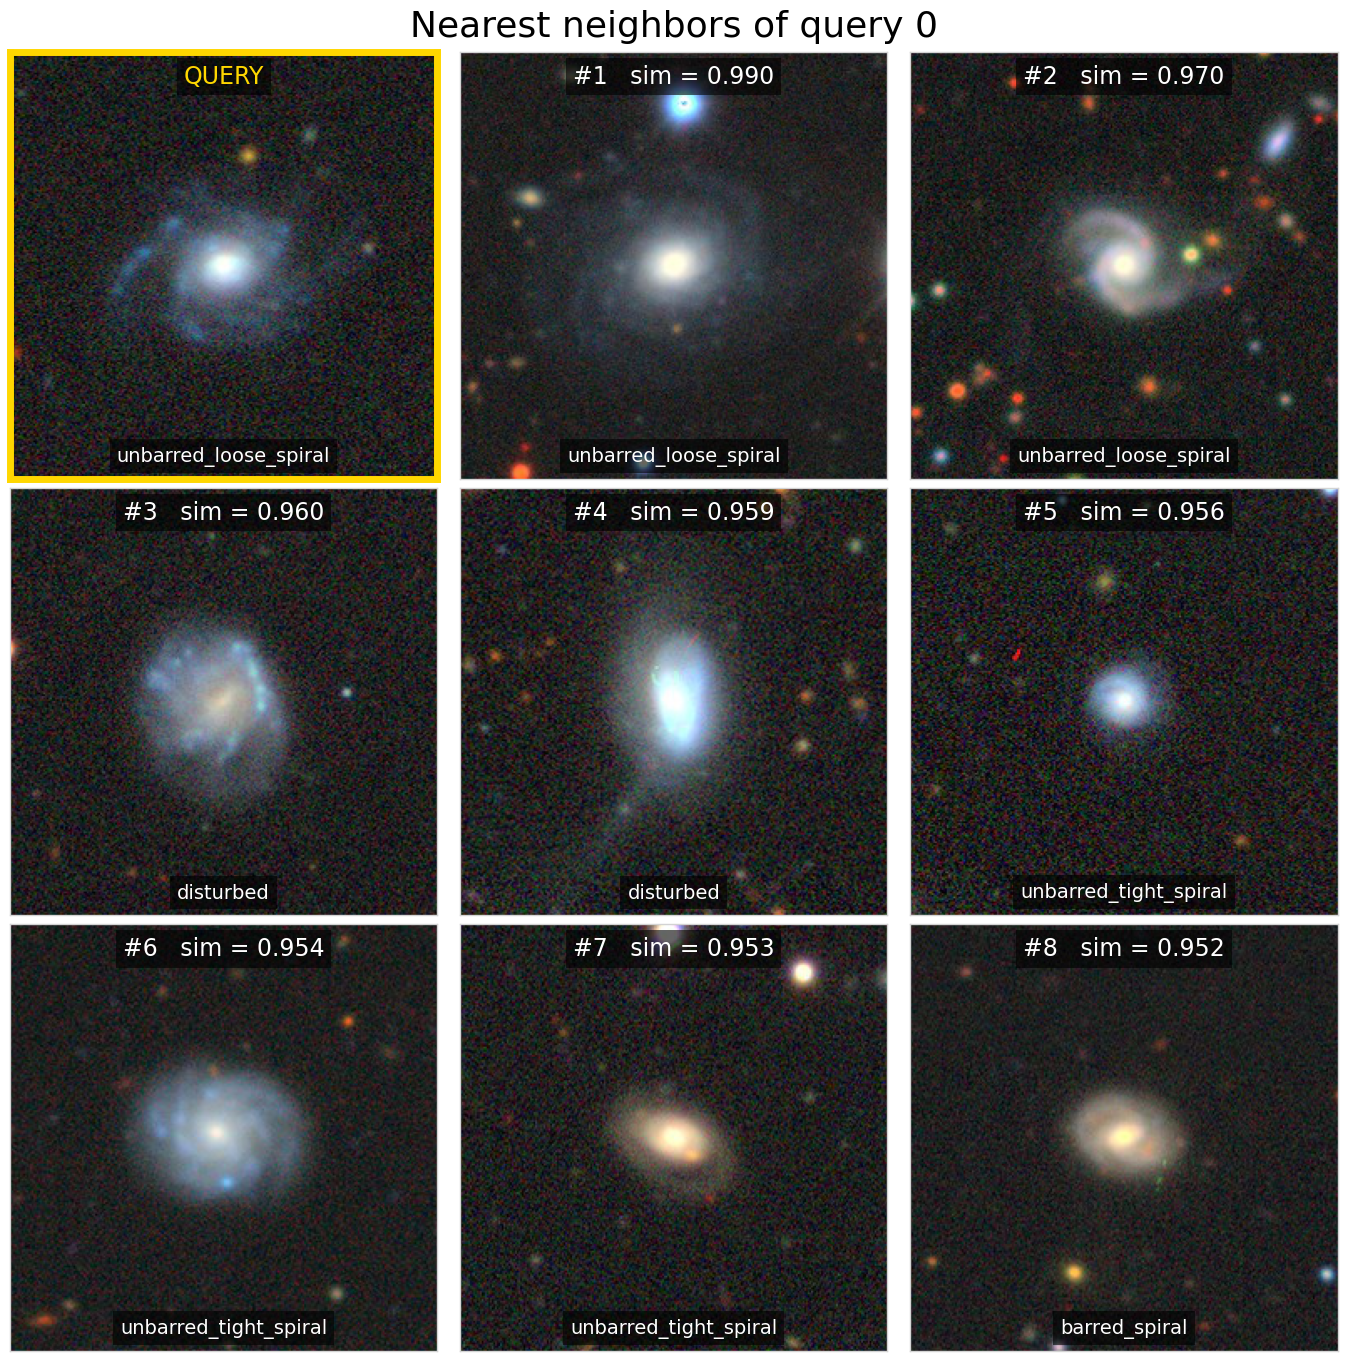

In [5]:
import io
from PIL import Image

TOP_N = 8
N_COLS = 3
QUERY_IDX = 0  # pick any position

def to_rgb(example):
    return Image.open(io.BytesIO(example["rgb_image"]["bytes"])).convert("RGB")

sims = cosine_similarity(embeddings[QUERY_IDX : QUERY_IDX + 1], embeddings)[0]
nearest = np.argsort(sims)[::-1][: TOP_N + 1]  # includes the query itself

n_rows = int(np.ceil(len(nearest) / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4.5 * N_COLS, 4.5 * n_rows), layout="constrained")
for rank, (ax, idx) in enumerate(zip(axes.flat, nearest)):
    is_query = idx == QUERY_IDX
    ax.imshow(to_rgb(examples[idx]))
    ax.text(
        0.5, 0.97,
        "QUERY" if is_query else f"#{rank}   sim = {sims[idx]:.3f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=17,
        color="gold" if is_query else "white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )
    ax.text(
        0.5, 0.03,
        gz10.CLASS_NAMES[examples[idx]["gz10_label"]],
        transform=ax.transAxes, ha="center", va="bottom", fontsize=14,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=5),
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set(color="gold" if is_query else "lightgray", linewidth=5 if is_query else 1)
for ax in axes.flat[len(nearest):]:
    ax.axis("off")
fig.suptitle(f"Nearest neighbors of query {QUERY_IDX}", fontsize=26)